In [206]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import vireoSNP

In [110]:
cwd = os.getcwd()

In [145]:
def match_sample_id():

    # match bulk to dissociated bulk
    res = vireoSNP.vcf.match_VCF_samples(
        cwd + "/../data/bcftools/bcftools_qual_dp_rm_4samples_filter_bulk_all.vcf",
        cwd + "/../data/bcftools/bcftools_qual_dp_rm_2507_filter_diss_bulk_all.vcf",
        GT_tag1="PL",
        GT_tag2="PL",
    )

    df = pd.DataFrame(
        {
            "diss bulk sample id": res["matched_donors2"],
            "bulk sample id": res["matched_donors1"],
        }
    )
    # Clean up "sample id" columns, only retain the sample id
    df = df.replace({r"\d{6}/": ""}, regex=True)

    return res, df

In [168]:
res, df = match_sample_id()

Shape for Geno Prob in VCF1: (184157, 31, 3)
Shape for Geno Prob in VCF2: (72931, 31, 3)
n_variants in VCF1, VCF2 and matched: 184157, 72931, 57631
aligned donors:
['230509/2129' '230509/2186' '230509/2202' '230509/2209' '230509/2309'
 '230509/2313' '230509/2401' '230509/2407' '230509/2444' '230509/2483'
 '230509/2526' '230626/2216' '230626/2221' '230626/2230' '230626/2238'
 '230626/2246' '230626/2249' '230626/2268' '230626/2278' '230626/2296'
 '230626/2364' '230626/2408' '230626/2416' '230626/2423' '230626/2430'
 '230626/2455' '230626/2460' '230626/2466' '230626/2477' '230626/2507'
 '230626/2514']
['230414/2129' '230418/2186' '230414/2202' '230418/2216' '230414/2313'
 '230414/2364' '230414/2407' '230414/2408' '230418/2455' '230414/2526'
 '230414/2209' '230414/2221' '230418/2230' '230414/2238' '230414/2240'
 '230414/2249' '230418/2246' '230414/2278' '230414/2018' '230414/2023'
 '230414/2401' '230414/2416' '230418/2094' '230418/2309' '230418/2423'
 '230414/2460' '230418/2466' '230414/24

In [169]:
# Save the dataframe with the matched sample IDs
pair_df = df.copy()
# Create a dataframe with the heatmap values
df = pd.DataFrame(
    res["matched_GPb_diff"],
    columns=res["matched_donors2"],
    index=res["matched_donors1"],
)
# Clean up the column and index names to remove the sample id prefix
# (only if the sample ids are unique in the columns and rows)
df.columns = df.columns.str.replace(r"\d{6}/", "", regex=True)
df.index = df.index.str.replace(r"\d{6}/", "", regex=True)

In [108]:
# remember_df = df.copy()

In [175]:
remember_df.shape

(31, 31)

In [176]:
set(remember_df.index) - set(df.index)

{'2018', '2023', '2094', '2126', '2240'}

In [179]:
extra_df = remember_df.loc[list(set(remember_df.index) - set(df.index))]

In [180]:
extra_df

,2018,2023,2094,2126,2129,2186,2202,2216,2246,2313,...,2278,2401,2416,2309,2423,2460,2466,2477,2483,2514
2094,0.176265,0.177039,0.022737,0.177075,0.175566,0.177312,0.169135,0.190543,0.182254,0.205824,...,0.191604,0.173255,0.223159,0.193734,0.193473,0.177847,0.180796,0.174573,0.184169,0.225088
2023,0.178282,0.029563,0.176936,0.177699,0.177327,0.177078,0.172251,0.186851,0.182401,0.206980,...,0.186857,0.171296,0.223198,0.190457,0.188496,0.179045,0.180150,0.172407,0.179863,0.226020
2240,0.177597,0.180595,0.181093,0.171687,0.177561,0.174564,0.179873,0.189724,0.035770,0.206293,...,0.187460,0.177670,0.216786,0.192899,0.190178,0.178156,0.181798,0.171389,0.182718,0.223410
2126,0.170341,0.177425,0.176833,0.024424,0.176662,0.170672,0.170815,0.186026,0.174747,0.203547,...,0.186925,0.172331,0.217159,0.192688,0.185961,0.178583,0.177824,0.172937,0.178388,0.224370
2018,0.023158,0.178846,0.175142,0.170035,0.178226,0.176731,0.172711,0.187050,0.179779,0.205365,...,0.187459,0.173651,0.220273,0.190621,0.185358,0.175236,0.178240,0.173811,0.180425,0.227560


In [181]:
test = pd.concat([df, extra_df])

In [185]:
extra_cols = list(set(test.index) - set(test.columns))

In [186]:
empty_extra_df = pd.DataFrame(
    [[np.nan] * len(extra_cols)] * len(df),
    index=df.index,
    columns=extra_cols
)

In [189]:
x = pd.concat([test, empty_extra_df], axis=1)

In [191]:
sorted(x.index)==sorted(x.columns)

True

In [198]:
x = x[sorted(x)]
x = x.loc[sorted(x.index)]

In [201]:
df = x.copy()

In [200]:
# x.to_csv("heatmap_qual_dp_all_samples.csv", index=True)

In [19]:
# Sample order for the heatmap plot when all bulk and dissociated bulk samples are included in both rows and columns
# sample_order_df = pd.DataFrame({"samples": sorted(set(df.columns) | set(df.index))})
# # Sort by sample type and sample id
# sample_order_df["sample_id"] = sample_order_df["samples"].str[-4:]
# sample_order_df["date"] = sample_order_df["samples"].str[:4]
# sample_order_df.loc[sample_order_df["date"] == "2304", "sample_type"] = "diss_bulk"
# sample_order_df.loc[sample_order_df["date"] != "2304", "sample_type"] = "bulk"
# sample_order_df = sample_order_df.sort_values(by=["sample_type", "sample_id"])

# sample_order_lst = list(sample_order_df["samples"])
# # Apply the sample order
# sorted_df = df[sample_order_lst]
# sorted_df = sorted_df.loc[sample_order_lst]

In [202]:
# Sample order for the heatmap plot when dissociated bulk samples are only in the columns and bulk samples are only in the rows
df.index = df.index.astype(str)
sorted_df = df[sorted(df.columns)]
sorted_df = sorted_df.loc[sorted(sorted_df.index)]

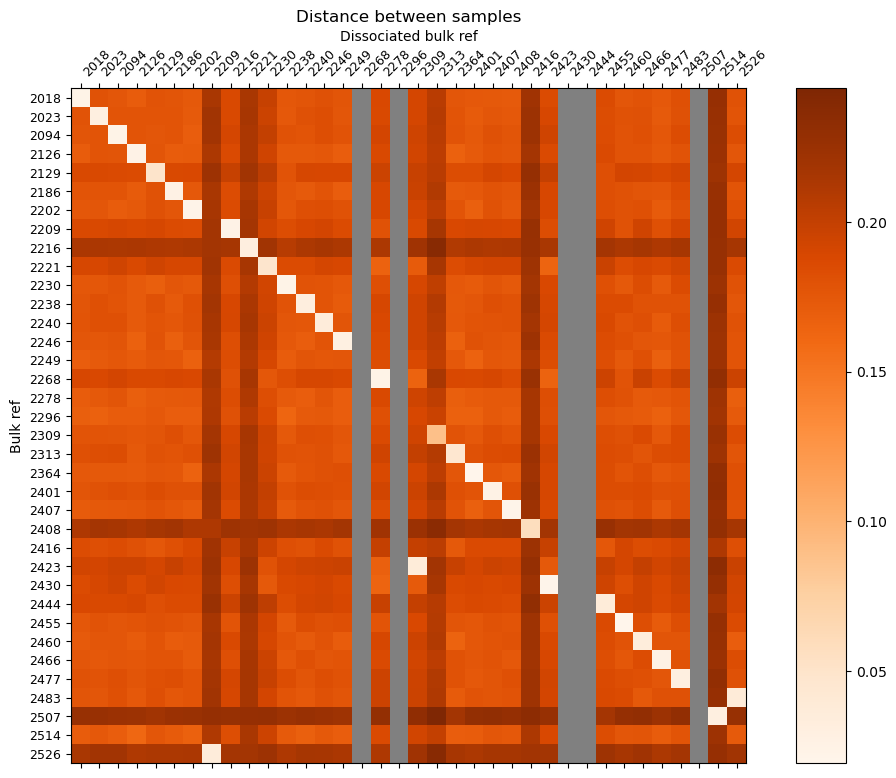

In [214]:
fig, ax = plt.subplots(figsize=(10, 10))
cmap = mpl.colormaps.get_cmap('Oranges')  # viridis is the default colormap for imshow
cmap.set_bad(color='grey')
heatmap = ax.matshow(sorted_df, cmap=cmap)

# # Numbers in grid
# for (i, j), z in np.ndenumerate(sorted_df):
#     ax.text(j, i, "{:.2f}".format(z), ha="center", va="center", fontdict={"fontsize": 6})

ax.set_xticks(np.arange(len(df.columns)))
ax.set_yticks(np.arange(len(df)))
ax.set_xticklabels(sorted_df.columns, rotation=45, ha="left", fontdict={"fontsize": 9})
ax.set_yticklabels(sorted_df.index, fontdict={"fontsize": 9})
ax.xaxis.set_label_position("top")
ax.set_xlabel("Dissociated bulk ref")
ax.set_ylabel("Bulk ref")
ax.set_title("Distance between samples")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size=0.5, pad=0.5)
cbar = fig.colorbar(heatmap, cax=cax)

plt.show()

In [216]:
filename = f"../figures/bulk_diss_bulk_heatmap_qual_dp900_w2507_all_samples"
fig.savefig(filename + ".pdf", bbox_inches="tight")
fig.savefig(filename + ".png", bbox_inches="tight")